# Ноутбук для ДЗ по `Трекинг экспериментов`

In [1]:
!python --version  # 3.12.10

Python 3.12.10


In [2]:
!pip install numpy==2.4.4 datasets==4.0.0 scikit-learn==1.8.0 catboost==1.2.10 mlflow==2.20.2 -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Импорты

In [3]:
# импорты для пайплайна

import numpy as np
from datasets import load_dataset
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from catboost import CatBoostRegressor, CatBoostClassifier

In [4]:
import mlflow

In [5]:
mlflow.set_tracking_uri('http://158.160.242.172:5000/')

In [6]:
mlflow.set_experiment(experiment_id='31')

<Experiment: artifact_location='mlflow-artifacts:/31', creation_time=1776962615415, experiment_id='31', last_update_time=1776964074265, lifecycle_stage='active', name='homework-davardanyan', tags={}>

### Константы

In [7]:
DATASET_NAME = 'scikit-learn/adult-census-income'
TEST_SIZE = 0.3
RANDOM_STATE = 42

## Скачивание и подготовка данных

Скачаем данные

In [8]:
dataset = load_dataset(DATASET_NAME)

Посмотрим на них и изучим

In [9]:
# dataset

In [10]:
# dataset['train'].features

In [11]:
df = dataset['train'].to_pandas()
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


Описание признаков:

- `age` &mdash; возраст человека
- `workclass` &mdash; тип занятости
- `fnlwgt` &mdash; вес наблюдения в данных переписи населения США (сколько реальных людей в популяции «представляет» эта строка)
- `education` &mdash; образование
- `education.num` &mdash; уровень образования в виде числа
- `marital.status` &mdash; семейное положение
- `occupation` &mdash; профессия / род деятельности
- `relationship` &mdash; роль человека в семье
- `race` &mdash; расовая группа
- `sex` &mdash; пол человека (`Male` / `Female`)
- `capital.gain` &mdash; доход от капитала (прибыль от продажи активов)
- `capital.loss` &mdash; убытки от капитала
- `hours.per.week` &mdash; количество рабочих часов в неделю
- `native.country` &mdash; страна происхождения

Описание таргета:

- `income` &mdash; бинарно, получает человек больше 50k $ в год или нет

Оставим только часть признаков

In [12]:
columns = [
    'age', 'workclass', 'education.num', 'occupation', 'marital.status', 
    'capital.gain', 'hours.per.week',
    'sex', 'race',
    'native.country', 'relationship',
]

target_column = 'income'

И разделим датафрейм на признаки и таргет

In [13]:
X, y = df[columns], df[target_column]

In [14]:
X

,age,workclass,education.num,occupation,marital.status,capital.gain,hours.per.week,sex,race,native.country,relationship
0,90,?,9,?,Widowed,0,40,Female,White,United-States,Not-in-family
1,82,Private,9,Exec-managerial,Widowed,0,18,Female,White,United-States,Not-in-family
2,66,?,10,?,Widowed,0,40,Female,Black,United-States,Unmarried
3,54,Private,4,Machine-op-inspct,Divorced,0,40,Female,White,United-States,Unmarried
4,41,Private,10,Prof-specialty,Separated,0,40,Female,White,United-States,Own-child
...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,10,Protective-serv,Never-married,0,40,Male,White,United-States,Not-in-family
32557,27,Private,12,Tech-support,Married-civ-spouse,0,38,Female,White,United-States,Wife
32558,40,Private,9,Machine-op-inspct,Married-civ-spouse,0,40,Male,White,United-States,Husband
32559,58,Private,9,Adm-clerical,Widowed,0,40,Female,White,United-States,Unmarried


In [15]:
y

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557    <=50K
32558     >50K
32559    <=50K
32560    <=50K
Name: income, Length: 32561, dtype: object

Используем Label Encoding для кодирования категориальных признаков

In [16]:
cat_features = [
    'workclass', 'occupation', 'marital.status',
    'sex', 'race', 
    'native.country', 'relationship'
]


reject_features = []

# reject_features = ["race"]
num_features = list(set(columns) - set(cat_features))
num_features = list(set(num_features) - set(reject_features))
cat_features = list(set(cat_features) - set(reject_features))

In [17]:
X = X.drop(columns=reject_features)

# Здесь начинается разнообразие

In [18]:
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, LabelEncoder, Normalizer, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
#         ('cat', OrdinalEncoder(), cat_features),
         ('cat', OneHotEncoder(), cat_features),
#         ('cat', TargetEncoder(), cat_features),
#         ('cat', LabelEncoder(), cat_features),
         ('num', StandardScaler(), num_features),
#         ('num', Normalizer(), num_features),
    ]
)

In [19]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

И закодируем целевую переменную

In [20]:
y.value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [21]:
y_transformed = (y == '>50K').astype(int)

In [22]:
y_transformed

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    0
32558    1
32559    0
32560    0
Name: income, Length: 32561, dtype: int64

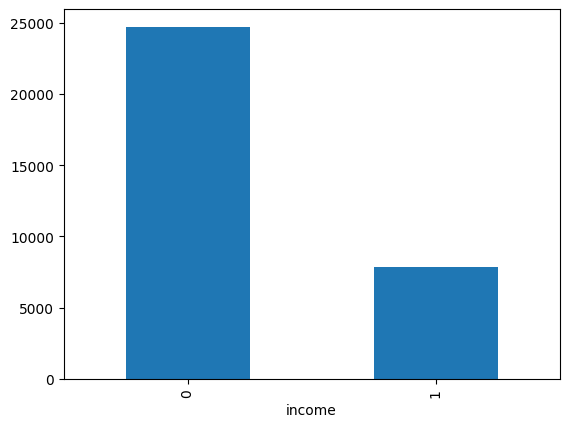

In [23]:
y_transformed.value_counts().plot.bar();

Разделим на train и test

In [24]:
X

,age,workclass,education.num,occupation,marital.status,capital.gain,hours.per.week,sex,race,native.country,relationship
0,90,?,9,?,Widowed,0,40,Female,White,United-States,Not-in-family
1,82,Private,9,Exec-managerial,Widowed,0,18,Female,White,United-States,Not-in-family
2,66,?,10,?,Widowed,0,40,Female,Black,United-States,Unmarried
3,54,Private,4,Machine-op-inspct,Divorced,0,40,Female,White,United-States,Unmarried
4,41,Private,10,Prof-specialty,Separated,0,40,Female,White,United-States,Own-child
...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,10,Protective-serv,Never-married,0,40,Male,White,United-States,Not-in-family
32557,27,Private,12,Tech-support,Married-civ-spouse,0,38,Female,White,United-States,Wife
32558,40,Private,9,Machine-op-inspct,Married-civ-spouse,0,40,Male,White,United-States,Husband
32559,58,Private,9,Adm-clerical,Widowed,0,40,Female,White,United-States,Unmarried


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=TEST_SIZE)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((22792, 11), (9769, 11), (22792,), (9769,))

## Обучение модели

В качестве бейзлайна возьмём логистическую регрессию

In [27]:
# CatBoost

model_params = dict(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=0,
)

In [28]:
# Tree

# model_params = dict( # DecisionTreeClassifier
#     criterion='gini', # “gini”, “entropy”, “log_loss”
#     splitter="best", # “best”, “random”
#     max_depth=16, # int
#     min_samples_split = 6, # int
#     min_samples_leaf=1, # int
#     random_state=RANDOM_STATE
# )
# model_params

In [29]:
# LogReg

# model_params = dict(
#     penalty='l2', C=0.1, solver='newton-cg', max_iter=120, random_state=RANDOM_STATE
# )
# model_params

In [30]:
model = CatBoostClassifier(**model_params, cat_features=cat_features)
# model

Соберем пайплайн целиком

In [31]:
# CatBoost сам обрабатывает категориальные признаки — препроцессор не нужен
pipeline = model
# pipeline

In [32]:
y_train

1842     1
12209    1
23187    0
5469     0
25047    0
        ..
31244    0
11342    0
27962    0
4911     0
14077    1
Name: income, Length: 22792, dtype: int64

И запустим обучение

In [33]:
pipeline.fit(X_train, y_train)
pipeline

CatBoostClassifier(cat_features=['sex', 'native.country', 'race', 'workclass', 'marital.status', 'occupation', 'relationship'], depth=6, iterations=500, l2_leaf_reg=3.0, learning_rate=0.1, random_seed=42, verbose=0)

## Оценка качества модели

Получим предсказания на тесте обученной модели

In [34]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [35]:
y_proba.shape

(9769,)

In [36]:
y_pred = np.where(y_proba >= 0.5, 1, 0)

Считаем метрики

In [37]:
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
    'pr_auc': average_precision_score(y_test, y_proba),
}

class_report = classification_report(y_test, y_pred)

In [38]:
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1-score: {metrics['f1']:.4f}")
print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
print(f"PR-AUC: {metrics['pr_auc']:.4f}")
print("="*60)
print(f"Classification Report:\n {class_report}")

Accuracy: 0.8665
Precision: 0.7563
Recall: 0.6557
F1-score: 0.7024
ROC-AUC: 0.9227
PR-AUC: 0.8107
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91      7422
           1       0.76      0.66      0.70      2347

    accuracy                           0.87      9769
   macro avg       0.83      0.79      0.81      9769
weighted avg       0.86      0.87      0.86      9769



In [39]:
run_label = "best"

In [40]:
X_example = X_test.iloc[:3].copy()
int_cols = X_example.select_dtypes(include='integer').columns
X_example[int_cols] = X_example[int_cols].astype('float64')

with mlflow.start_run(run_name=run_label):
    mlflow.log_params(model_params)
    mlflow.log_params(
        {
            'cat_features': cat_features,
            'num_features': num_features,
            'preprocessing': 'catboost_native',
            'class_report': class_report
        }
    )
    mlflow.log_metrics(metrics)
    mlflow.catboost.log_model(
        pipeline,
        artifact_path='model',
        input_example=X_example,
    )
    
#     mlflow.log_artifact('test_text.txt')

E:\AAA\sem2\ML_SD\MLFlow\DZ\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run best at: http://158.160.242.172:5000/#/experiments/31/runs/886cba392dcf48d8a62942843ac8532a
🧪 View experiment at: http://158.160.242.172:5000/#/experiments/31


In [ ]:
model_uri = 'mlflow-artifacts:/31/d0dccfe73fcd44439d5340da3c860415/artifacts/model'

In [ ]:
pipeline_1 = mlflow.pyfunc.load_model(model_uri)

In [ ]:
pipeline_1